## 1. Data

This project uses synthetic detector-like signals generated in Python.

No external experimental data is used. The simulated signals are designed to model simplified detector pulses with added noise and background, inspired by particle and rare-event detector analysis.

## 2. Generating a Clean Detector Pulse

A simplified detector pulse can be represented using a Gaussian function:

$$
S(t) = A e^{-\frac{(t - t_0)^2}{2\sigma^2}}
$$

where:
- $A$ is the pulse amplitude
- $t_0$ is the event time
- $\sigma$ controls the pulse width
- $t$ is time

This is a simplified model of a detector response after an event deposits energy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
np.random.seed(42)

### Reproducibility

A random seed is used so that the simulated noise is reproducible each time the notebook is run.

In [2]:
t = np.linspace(0, 10, 1000)
A = 1.0
t0 = 5.0
sigma = 0.3
signal = A * np.exp(-((t - t0)**2) / (2 * sigma**2))

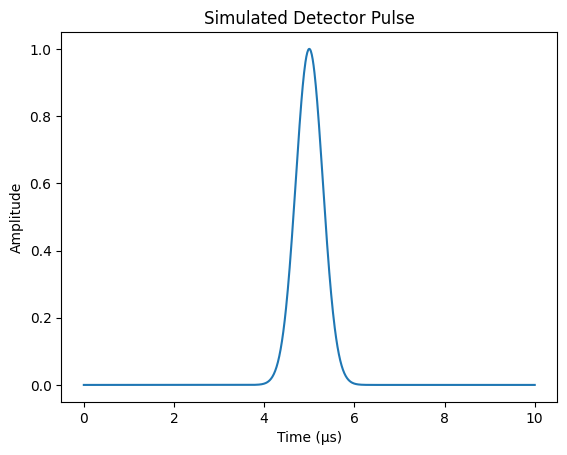

In [4]:
plt.plot(t, signal)
plt.title('Simulated Detector Pulse')
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude')
plt.show()

### Interpretation

The simulated detector pulse is centered at $t_0 = 5.0\ \mu s$, with a maximum amplitude of approximately 1.0. The Gaussian shape represents an idealized detector response to a single event. The pulse width is controlled by $\sigma$, where a smaller value produces a narrower pulse and a larger value produces a broader pulse.

## 3. Adding Gaussian Noise

Real detector signals contain noise from electronics, background radiation, and measurement uncertainty. To make the simulated signal more realistic, I add random Gaussian noise to the clean pulse.

In [5]:
noise_level = 0.1
noise = np.random.normal(0, noise_level, size=len(t))
noisy_signal = signal + noise

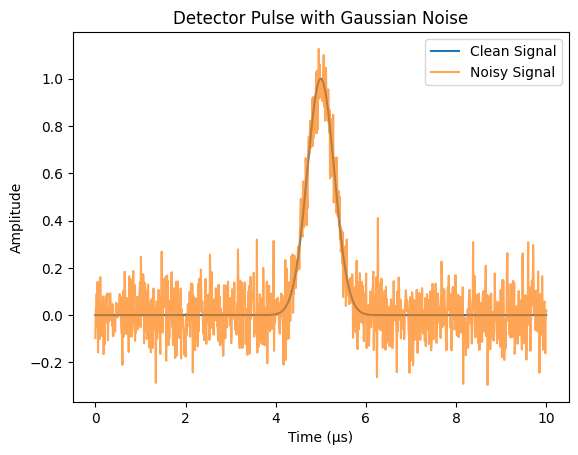

In [6]:
plt.plot(t, signal, label="Clean Signal")
plt.plot(t, noisy_signal, label="Noisy Signal", alpha=0.7)

plt.title("Detector Pulse with Gaussian Noise")
plt.xlabel("Time (µs)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

## 4. Threshold-Based Event Detection

A simple way to detect events in a noisy detector signal is to set an amplitude threshold. If the signal rises above this threshold, the detector records a possible event.

This method is simple, but it has limitations:
- If the threshold is too low, noise may be mistaken for real events.
- If the threshold is too high, real events may be missed.

In [7]:
threshold = 0.5
above_threshold = noisy_signal > threshold

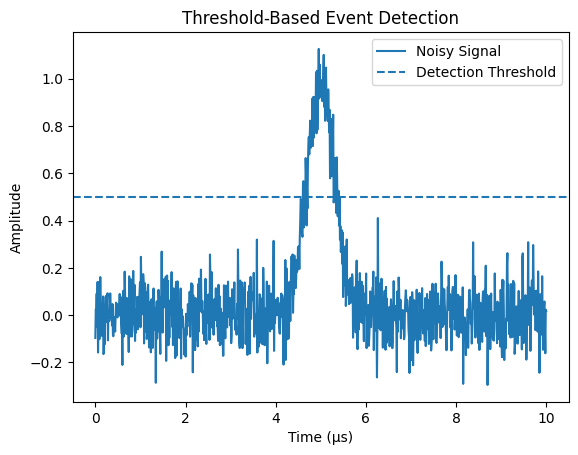

In [8]:
plt.plot(t, noisy_signal, label="Noisy Signal")
plt.axhline(threshold, linestyle="--", label="Detection Threshold")

plt.title("Threshold-Based Event Detection")
plt.xlabel("Time (µs)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

### Interpretation

The noisy detector signal rises above the chosen threshold near the location of the simulated pulse. This indicates that the event would be detected using a simple threshold-based method. However, the choice of threshold is important because random noise fluctuations can also cross the threshold if it is set too low.

## 5. Automatic Peak Detection

Instead of visually inspecting the signal, the next step is to automatically identify the highest point in the noisy detector signal. This allows us to estimate the event time and measured pulse amplitude.

In [9]:
peak_index = np.argmax(noisy_signal)

peak_time = t[peak_index]
peak_amplitude = noisy_signal[peak_index]

print("Peak time:", peak_time, "µs")
print("Peak amplitude:", peak_amplitude)

Peak time: 4.954954954954955 µs
Peak amplitude: 1.1259647681791936


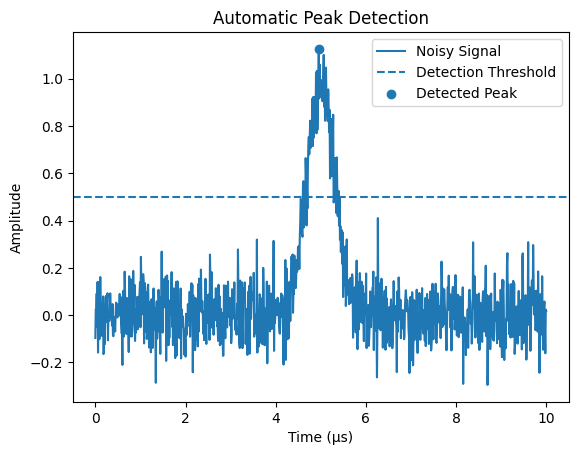

In [10]:
plt.plot(t, noisy_signal, label="Noisy Signal")
plt.axhline(threshold, linestyle="--", label="Detection Threshold")

plt.scatter(peak_time, peak_amplitude, label="Detected Peak", zorder=5)

plt.title("Automatic Peak Detection")
plt.xlabel("Time (µs)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

### Interpretation

The automatic peak detection method identifies the maximum amplitude in the noisy detector signal. The detected peak occurs at $4.955 \mu s$ which is close to the true simulated event time of $t_0 = 5.0\ \mu s$, showing that the event can still be recovered even after Gaussian noise is added.

In [11]:
time_error = abs(peak_time - t0)

print("True event time:", t0, "µs")
print("Detected peak time:", peak_time, "µs")
print("Timing error:", time_error, "µs")

True event time: 5.0 µs
Detected peak time: 4.954954954954955 µs
Timing error: 0.04504504504504503 µs


### Interpretation 
The timing error is small, indicating that the peak detection method can estimate the event time accurately for this noise level.

## 6. Effect of Noise Level on Peak Detection

To understand how detector noise affects event reconstruction, I compare signals with different noise levels. Higher noise levels may make it harder to accurately identify the true event time and pulse amplitude.

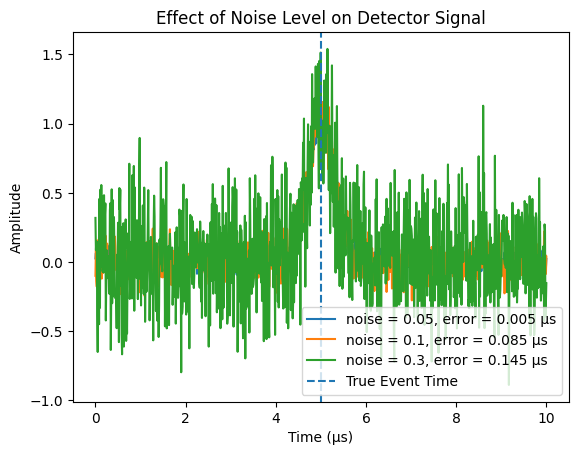

In [12]:
noise_levels = [0.05, 0.1, 0.3]

for noise_level in noise_levels:
    noise = np.random.normal(0, noise_level, size=len(t))
    noisy_signal = signal + noise

    peak_index = np.argmax(noisy_signal)
    peak_time = t[peak_index]
    time_error = abs(peak_time - t0)

    plt.plot(t, noisy_signal, label=f"noise = {noise_level}, error = {time_error:.3f} µs")

plt.axvline(t0, linestyle="--", label="True Event Time")

plt.title("Effect of Noise Level on Detector Signal")
plt.xlabel("Time (µs)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

### Interpretation

As the noise level increases, the random fluctuations in the detector signal become larger, making the pulse harder to distinguish from the background. At low and moderate noise levels, the detected peak remains close to the true event time. At higher noise levels, the timing error increases because random noise can shift the maximum detected amplitude away from the true pulse center.

This trend can be seen in the plot above. With a low noise level of 0.05, the timing error is small at approximately $0.005\ \mu s$. When the noise level increases to 0.1, the error increases to approximately $0.085\ \mu s$. At the highest tested noise level of 0.3, the timing error increases further to approximately $0.145\ \mu s$. This suggests that higher noise levels reduce the precision of event-time reconstruction.

## 7. Monte Carlo Simulation of Event Detection

A Monte Carlo simulation repeats a random process many times to study the average behavior of a system. Here, I repeat the detector simulation many times with random noise to estimate how reliably the event can be detected.

In [14]:
n_trials = 1000
noise_level = 0.1
threshold = 0.5

timing_errors = []
detected_events = 0

In [15]:
for i in range(n_trials):
    noise = np.random.normal(0, noise_level, size=len(t))
    noisy_signal = signal + noise

    peak_index = np.argmax(noisy_signal)
    peak_time = t[peak_index]
    peak_amplitude = noisy_signal[peak_index]

    if peak_amplitude > threshold:
        detected_events += 1
        time_error = abs(peak_time - t0)
        timing_errors.append(time_error)

In [16]:
detection_efficiency = detected_events / n_trials
average_timing_error = np.mean(timing_errors)

print("Detected events:", detected_events)
print("Total trials:", n_trials)
print("Detection efficiency:", detection_efficiency)
print("Average timing error:", average_timing_error, "µs")

Detected events: 1000
Total trials: 1000
Detection efficiency: 1.0
Average timing error: 0.05525525525525524 µs


### Interpretation

For a noise level of 0.1 and a detection threshold of 0.5, the simulated detector identified the event in all 1000 Monte Carlo trials, giving a detection efficiency of 100%. The average timing error was approximately $0.055\ \mu s$, indicating that the peak detection method was able to reconstruct the event time accurately under these conditions. However, because the signal amplitude is large compared with the noise level, this represents a relatively favorable detection scenario.

In [19]:
noise_levels = [0.05, 0.1, 0.2, 0.3, 0.5]

results = []

for noise_level in noise_levels:
    detected_events = 0
    timing_errors = []

    for i in range(n_trials):
        noise = np.random.normal(0, noise_level, size=len(t))
        noisy_signal = signal + noise

        peak_index = np.argmax(noisy_signal)
        peak_time = t[peak_index]
        peak_amplitude = noisy_signal[peak_index]

        if peak_amplitude > threshold:
            detected_events += 1
            time_error = abs(peak_time - t0)
            timing_errors.append(time_error)

    detection_efficiency = detected_events / n_trials
    average_timing_error = np.mean(timing_errors)

    results.append({
        "noise_level": noise_level,
        "detection_efficiency": detection_efficiency,
        "average_timing_error": average_timing_error
    })

In [20]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,noise_level,detection_efficiency,average_timing_error
0,0.05,1.0,0.037037
1,0.10,1.0,0.050280
2,0.20,1.0,0.073524
3,0.30,1.0,0.087938
4,0.50,1.0,0.247257


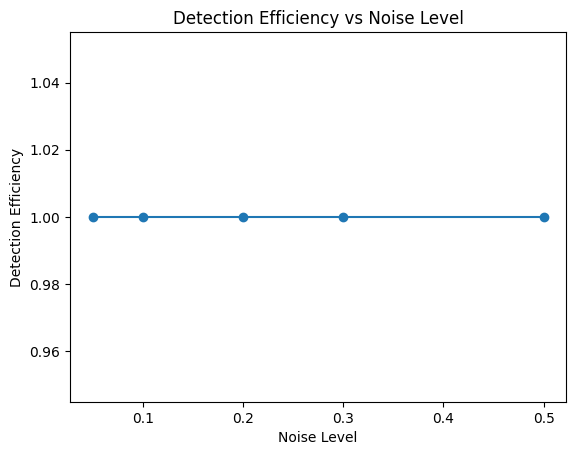

In [21]:
plt.plot(results_df["noise_level"], results_df["detection_efficiency"], marker="o")
plt.xlabel("Noise Level")
plt.ylabel("Detection Efficiency")
plt.title("Detection Efficiency vs Noise Level")
plt.show()

### Interpretation

Across all tested noise levels, the detection efficiency remained at 1.0, meaning the simulated event was detected in all Monte Carlo trials. This suggests that, for the chosen signal amplitude and detection threshold, the event remains strong enough to be identified even as noise increases.

However, the average timing error increases with noise level. At low noise, the reconstructed peak time remains close to the true event time. At higher noise levels, random fluctuations increasingly shift the detected maximum away from the true pulse center. This shows that while event detection remains reliable in this setup, the precision of event-time reconstruction decreases as noise increases.

## 8. Effect of Detection Threshold on Event Detection

The detection threshold determines how large a signal must be before it is counted as an event. A low threshold may detect events more easily, but it may also be more sensitive to noise. A high threshold reduces false detections from noise, but may miss weaker real events.

In this section, I test how detection efficiency changes as the threshold is varied.

In [22]:
threshold_values = [0.2, 0.4, 0.6, 0.8, 1.0]
noise_level = 0.3
n_trials = 1000

threshold_results = []

In [23]:
for threshold in threshold_values:
    detected_events = 0
    timing_errors = []

    for i in range(n_trials):
        noise = np.random.normal(0, noise_level, size=len(t))
        noisy_signal = signal + noise

        peak_index = np.argmax(noisy_signal)
        peak_time = t[peak_index]
        peak_amplitude = noisy_signal[peak_index]

        if peak_amplitude > threshold:
            detected_events += 1
            time_error = abs(peak_time - t0)
            timing_errors.append(time_error)

    detection_efficiency = detected_events / n_trials

    if len(timing_errors) > 0:
        average_timing_error = np.mean(timing_errors)
    else:
        average_timing_error = np.nan

    threshold_results.append({
        "threshold": threshold,
        "detection_efficiency": detection_efficiency,
        "average_timing_error": average_timing_error
    })

In [24]:
threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,threshold,detection_efficiency,average_timing_error
0,0.2,1.0,0.098629
1,0.4,1.0,0.090330
2,0.6,1.0,0.092633
3,0.8,1.0,0.091471
4,1.0,1.0,0.094154


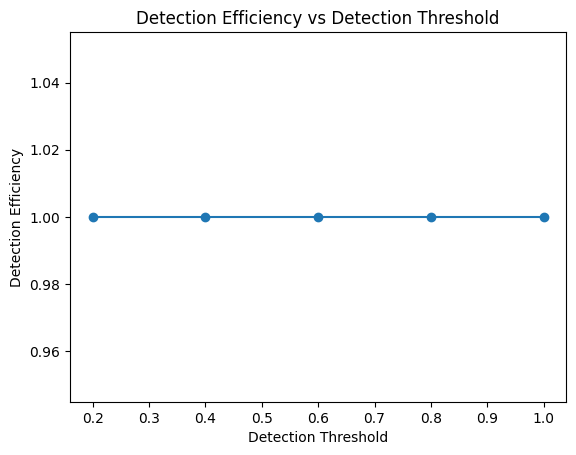

In [25]:
plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["detection_efficiency"],
    marker="o"
)

plt.title("Detection Efficiency vs Detection Threshold")
plt.xlabel("Detection Threshold")
plt.ylabel("Detection Efficiency")
plt.show()

### Interpretation

Across all tested detection thresholds, the detection efficiency remained at 1.0, meaning the event was detected in all 1000 Monte Carlo trials for each threshold value. This suggests that, under the current simulation conditions, the detector pulse is strong enough to be identified even when the threshold is increased.

However, this also indicates that the current setup represents a relatively favorable detection scenario. Since the pulse amplitude is approximately 1.0 and Gaussian noise is added to the signal, the measured peak often remains above the tested thresholds. As a result, increasing the threshold from 0.2 to 1.0 does not reduce the detection efficiency in this case.

The average timing error remains around $0.09\ \mu s$ across the tested thresholds, suggesting that changing the threshold does not strongly affect timing reconstruction when the event is clearly detectable. To observe a stronger threshold effect, the simulation could be made more challenging by lowering the signal amplitude, increasing the noise level, or testing thresholds above 1.0.

## 9. Threshold Effects for a Weaker Signal

The previous threshold test used a relatively strong pulse amplitude of $A = 1.0$, which resulted in 100% detection efficiency across all tested thresholds. To make the detection problem more challenging, I repeat the threshold study using a weaker pulse with amplitude $A = 0.5$.

This allows us to test how threshold choice affects detection efficiency when the signal is closer in size to the noise background.

In [26]:
A_weak = 0.5
weak_signal = A_weak * np.exp(-((t - t0)**2) / (2 * sigma**2))

threshold_values = [0.2, 0.4, 0.6, 0.8, 1.0]
noise_level = 0.3
n_trials = 1000

weak_threshold_results = []

for threshold in threshold_values:
    detected_events = 0
    timing_errors = []

    for i in range(n_trials):
        noise = np.random.normal(0, noise_level, size=len(t))
        noisy_signal = weak_signal + noise

        peak_index = np.argmax(noisy_signal)
        peak_time = t[peak_index]
        peak_amplitude = noisy_signal[peak_index]

        if peak_amplitude > threshold:
            detected_events += 1
            time_error = abs(peak_time - t0)
            timing_errors.append(time_error)

    detection_efficiency = detected_events / n_trials

    if len(timing_errors) > 0:
        average_timing_error = np.mean(timing_errors)
    else:
        average_timing_error = np.nan

    weak_threshold_results.append({
        "threshold": threshold,
        "detection_efficiency": detection_efficiency,
        "average_timing_error": average_timing_error
    })

weak_threshold_results_df = pd.DataFrame(weak_threshold_results)
weak_threshold_results_df

,threshold,detection_efficiency,average_timing_error
0,0.2,1.000,0.473794
1,0.4,1.000,0.438488
2,0.6,1.000,0.489239
3,0.8,1.000,0.505746
4,1.0,0.927,0.463630


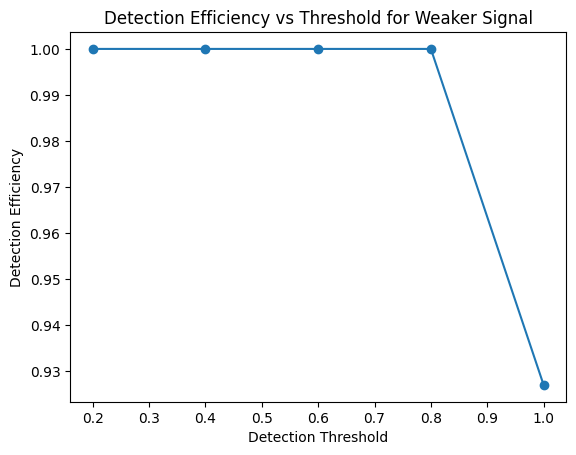

In [27]:
plt.plot(
    weak_threshold_results_df["threshold"],
    weak_threshold_results_df["detection_efficiency"],
    marker="o"
)

plt.title("Detection Efficiency vs Threshold for Weaker Signal")
plt.xlabel("Detection Threshold")
plt.ylabel("Detection Efficiency")
plt.show()

### Interpretation

For the weaker signal with amplitude \(A = 0.5\), the detection efficiency remains at 1.0 for thresholds between 0.2 and 0.8. This means the event was detected in all Monte Carlo trials at these thresholds. However, when the threshold is increased to 1.0, the detection efficiency drops to 0.927, meaning that some events are no longer detected.

This shows that threshold choice becomes more important when the signal amplitude is smaller. At lower thresholds, the event is easier to detect, while at higher thresholds, weaker events may be missed. The fact that detection efficiency remains high even for thresholds above the clean signal amplitude also reflects the effect of noise, which can sometimes increase the measured peak amplitude.

Overall, this test shows that weaker signals are more sensitive to threshold choice, and that overly strict thresholds can reduce detection efficiency.The average timing error is also larger for the weaker signal, suggesting that weaker pulses are more strongly affected by noise. Even when the event is detected, the measured peak may be shifted away from the true event time.

## 10. Background-Only False Positive Study

In rare-event detector analysis, it is important to understand not only whether real events are detected, but also whether random background or noise fluctuations can be mistaken for real events.

In this section, I simulate background-only signals with no true detector pulse. I then apply the same threshold-based detection method to estimate the false positive rate.

In [28]:
background_signal = noise

In [29]:
threshold_values = [0.2, 0.4, 0.6, 0.8, 1.0]
noise_level = 0.3
n_trials = 1000

false_positive_results = []

for threshold in threshold_values:
    false_positives = 0

    for i in range(n_trials):
        background_signal = np.random.normal(0, noise_level, size=len(t))

        peak_amplitude = np.max(background_signal)

        if peak_amplitude > threshold:
            false_positives += 1

    false_positive_rate = false_positives / n_trials

    false_positive_results.append({
        "threshold": threshold,
        "false_positive_rate": false_positive_rate
    })

false_positive_df = pd.DataFrame(false_positive_results)
false_positive_df

,threshold,false_positive_rate
0,0.2,1.000
1,0.4,1.000
2,0.6,1.000
3,0.8,0.988
4,1.0,0.340


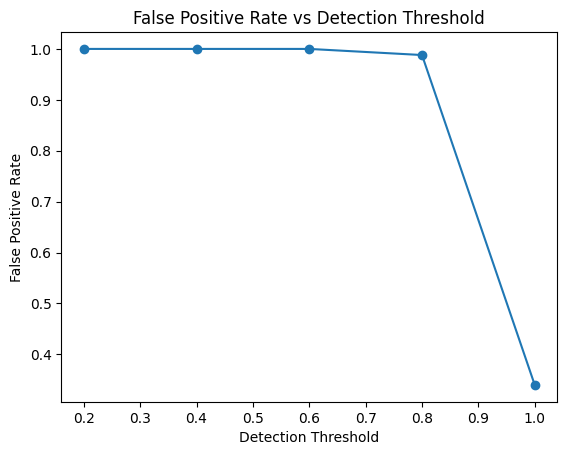

In [30]:
plt.plot(
    false_positive_df["threshold"],
    false_positive_df["false_positive_rate"],
    marker="o"
)

plt.title("False Positive Rate vs Detection Threshold")
plt.xlabel("Detection Threshold")
plt.ylabel("False Positive Rate")
plt.show()

### Interpretation

The background-only simulation shows that low detection thresholds produce very high false positive rates. For thresholds of 0.2, 0.4, and 0.6, the false positive rate is 1.0, meaning that random noise alone crossed the threshold in every Monte Carlo trial. Even at a threshold of 0.8, the false positive rate remains very high at 0.988.

When the threshold is increased to 1.0, the false positive rate drops to 0.340. This shows that stricter thresholds reduce the chance of mistaking noise fluctuations for real detector events.

However, this result also reveals a limitation of the simple detection method used here. Since the algorithm identifies the maximum value anywhere in the signal, random noise spikes can be incorrectly classified as events. This demonstrates the tradeoff between sensitivity and false positives: lower thresholds are better for detecting weak signals, but they also increase the risk of detecting background noise as a false event.

## 11. Improving the Detection Method

The simple threshold method used so far identifies the maximum amplitude anywhere in the signal. While this works well when a real pulse is present, the background-only study showed that random noise spikes can also cross the threshold and be incorrectly counted as events.

To improve the method, I add a timing-window requirement. Instead of accepting any peak above threshold, the algorithm only counts an event if the detected peak occurs near the expected event time.

In [31]:
window_start = 4.5
window_end = 5.5

In [32]:
threshold_values = [0.2, 0.4, 0.6, 0.8, 1.0]
noise_level = 0.3
n_trials = 1000

windowed_false_positive_results = []

for threshold in threshold_values:
    false_positives = 0

    for i in range(n_trials):
        background_signal = np.random.normal(0, noise_level, size=len(t))

        peak_index = np.argmax(background_signal)
        peak_time = t[peak_index]
        peak_amplitude = background_signal[peak_index]

        in_time_window = (peak_time >= window_start) and (peak_time <= window_end)

        if peak_amplitude > threshold and in_time_window:
            false_positives += 1

    false_positive_rate = false_positives / n_trials

    windowed_false_positive_results.append({
        "threshold": threshold,
        "false_positive_rate": false_positive_rate
    })

windowed_false_positive_df = pd.DataFrame(windowed_false_positive_results)
windowed_false_positive_df

,threshold,false_positive_rate
0,0.2,0.107
1,0.4,0.114
2,0.6,0.092
3,0.8,0.104
4,1.0,0.038


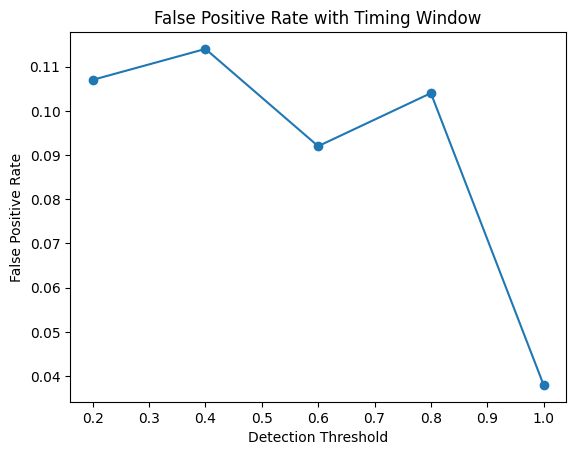

In [33]:
plt.plot(
    windowed_false_positive_df["threshold"],
    windowed_false_positive_df["false_positive_rate"],
    marker="o"
)

plt.title("False Positive Rate with Timing Window")
plt.xlabel("Detection Threshold")
plt.ylabel("False Positive Rate")
plt.show()

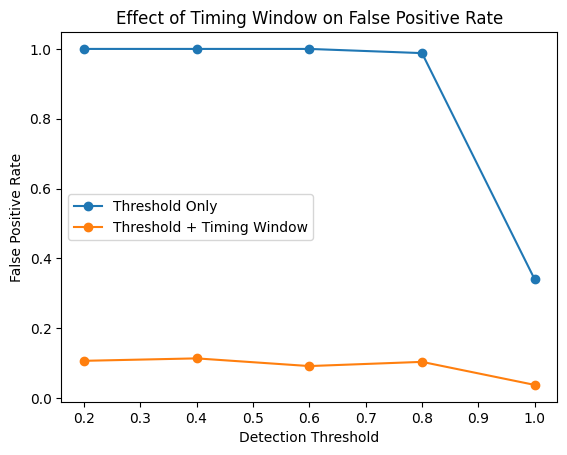

In [34]:
plt.plot(
    false_positive_df["threshold"],
    false_positive_df["false_positive_rate"],
    marker="o",
    label="Threshold Only"
)

plt.plot(
    windowed_false_positive_df["threshold"],
    windowed_false_positive_df["false_positive_rate"],
    marker="o",
    label="Threshold + Timing Window"
)

plt.title("Effect of Timing Window on False Positive Rate")
plt.xlabel("Detection Threshold")
plt.ylabel("False Positive Rate")
plt.legend()
plt.show()

### Interpretation

Adding a timing-window requirement greatly reduces the false positive rate compared with using a threshold alone. In the threshold-only method, random noise spikes anywhere in the signal could be counted as events, which produced very high false positive rates. For example, at thresholds of 0.2, 0.4, and 0.6, the false positive rate was 1.0, meaning every background-only trial produced a false detection.

After adding the timing-window requirement, the false positive rate dropped to approximately 0.09–0.11 for thresholds between 0.2 and 0.8, and further decreased to 0.038 at a threshold of 1.0. This shows that requiring the detected peak to occur near the expected event time rejects many random noise spikes that occur outside the signal region.

This demonstrates an important tradeoff in detector analysis. A simple threshold method is sensitive, but it may not be selective enough in noisy or background-only conditions. Adding additional criteria, such as a timing window, can improve background rejection and reduce false positives. However, this method assumes that the approximate event time is known in advance. In real detector systems, more sophisticated methods such as matched filtering, pulse-shape analysis, coincidence detection, or background modelling may be needed.

## 12. Summary of Key Results

This project simulated simplified detector-like signals and explored how noise, threshold choice, signal amplitude, and timing-window requirements affect event detection.

The analysis began with an ideal Gaussian detector pulse, then added Gaussian noise to create more realistic detector-like signals. A simple threshold-based method was used to detect events, followed by Monte Carlo simulations to evaluate detection efficiency, timing error, and false positive rates.

### Key Findings

| Test | Main Result | Interpretation |
|---|---|---|
| Clean Gaussian pulse | Pulse centered near \(t_0 = 5.0\ \mu s\) | The simplified detector response behaves as expected. |
| Noisy signal | Event still visible after Gaussian noise is added | Noise makes the signal more realistic but does not fully hide the pulse. |
| Automatic peak detection | Detected peak occurred close to true event time | The event time can be reconstructed with small timing error under favorable conditions. |
| Increasing noise level | Detection efficiency stayed high, but timing error increased | Higher noise reduces timing precision even when events are still detected. |
| Strong signal threshold test | Detection efficiency remained at 100% | The signal was strong enough that threshold choice had little effect. |
| Weak signal threshold test | Detection efficiency dropped at high threshold | Weaker signals are more sensitive to threshold choice. |
| Background-only test | Threshold-only method produced many false positives | Noise spikes can be mistaken for real events. |
| Timing-window improvement | False positive rate dropped significantly | Adding timing information improves background rejection. |

## Conclusion

This project demonstrates a simplified detector signal analysis pipeline using Python. A Gaussian pulse was used to model an idealized detector event, and Gaussian noise was added to simulate more realistic measurement conditions. I then applied threshold-based event detection, automatic peak finding, timing-error calculation, and Monte Carlo simulations to evaluate detector performance.

The results show that detection efficiency can remain high when the signal amplitude is large compared with the noise. However, increasing noise reduces the precision of event-time reconstruction. When the signal amplitude is reduced, detection becomes more sensitive to the choice of threshold, showing that weaker signals are more difficult to identify reliably.

The background-only simulation revealed an important limitation of a simple threshold-only method: random noise spikes can be incorrectly classified as events. Adding a timing-window requirement significantly reduced the false positive rate, demonstrating how additional selection criteria can improve background rejection.

Overall, this project highlights key ideas relevant to detector analysis, including noise, thresholds, event reconstruction, Monte Carlo simulation, detection efficiency, and false positive rates. While the simulation is simplified, it provides a foundation for understanding how detector performance can be studied computationally.

## Future Improvements

This project could be extended in several ways:

- Simulate multiple pulses in a single time window.
- Add background events with random arrival times.
- Compare different pulse shapes, such as exponential decay or asymmetric detector responses.
- Use matched filtering to improve signal detection in noisy data.
- Study how detection efficiency changes with both signal amplitude and noise level.
- Add false negative analysis for weak signals.
- Simulate energy-like spectra using pulse amplitudes.
- Compare threshold-based detection with more advanced peak-finding algorithms.
- Explore coincidence detection, where two related signals must be detected within a time window.